# Week 11 · Day 4 — RNN vs LSTM vs GRU on Shakespeare + a Text-Generation App

Yesterday we compared RNN and LSTM on a tiny corpus. Today we go bigger: train **all three** sequence models — **SimpleRNN, LSTM, GRU** — on **word-level Shakespeare**, compare them, **save each model to disk**, and build a **small app** that loads a saved model and generates text.

**Today:**
1. Load a larger corpus (Shakespeare) and prepare it
2. Train **RNN, LSTM, GRU** — same setup, three models
3. Compare them (accuracy, loss, sample text, training time)
4. **Save** all three models + the tokenizer to disk
5. Build a **local app** (Gradio) that loads a model and generates text

> **Kaggle GPU:** Settings → Accelerator → GPU. Add the **Shakespeare** dataset as an input (or the notebook downloads a copy).

In [1]:
import os, time, pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Input
from tensorflow.keras.models import load_model

tf.random.set_seed(42)
print("TF:", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.10.1 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 1. Load & prepare the Shakespeare corpus

We use the well-known **tiny Shakespeare** text. Keras can download it directly. We do **word-level** generation (predict the next *word*), which is more coherent than character-level.

In [27]:
# download tiny-shakespeare (or point PATH at an added Kaggle dataset file)
path = tf.keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt")
text = open(path).read().lower()



In [28]:
len(text)

1115394

In [29]:
# keep it a manageable size so 3 models train in a class session
text = text[:40000]
print("characters:", len(text))
print("\nsample:\n", text[:250])

characters: 40000

sample:
 first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.



In [30]:
# split into lines, tokenize into words
lines = [ln.strip() for ln in text.split("\n") if len(ln.strip().split()) > 2]

lines[:5]

['before we proceed any further, hear me speak.',
 'you are all resolved rather to die than to famish?',
 'first, you know caius marcius is chief enemy to the people.',
 "we know't, we know't.",
 "let us kill him, and we'll have corn at our own price."]

In [31]:
len(lines)

905

In [54]:


tokenizer = Tokenizer()
tokenizer.fit_on_texts(lines)
total_words = len(tokenizer.word_index) + 1
print("lines:", len(lines), "| vocabulary size:", total_words)

lines: 905 | vocabulary size: 1783


In [55]:
# build n-gram sequences: predict the next word from the words before it
input_sequences = []
for line in lines:
    ids = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(ids)):
        input_sequences.append(ids[:i + 1])

In [56]:
max([len(s) for s in input_sequences])

12

In [57]:
input_sequences[0][-12:]

[113, 19]

In [58]:
# cap sequence length so training stays fast
MAX_LEN = 12
input_sequences = [s[-MAX_LEN:] for s in input_sequences]
input_sequences = pad_sequences(input_sequences, maxlen=MAX_LEN, padding="pre")

In [59]:
input_sequences[:5][0].size

12

In [60]:




X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=total_words)
print("training samples:", X.shape, "| labels:", y.shape)

training samples: (5933, 11) | labels: (5933, 1783)


In [61]:
X[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 113])

In [62]:
y[0]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

---
## 2. Train RNN, LSTM, and GRU

Same architecture for all three — only the recurrent layer changes. A small factory builds each, so the comparison is fair. We record **training time** too, since speed is a real trade-off.

In [63]:
print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

print("X size:", X.nbytes / (1024**3), "GB")
print("y size:", y.nbytes / (1024**3), "GB")

X: (5933, 11) int32
y: (5933, 1783) float32
X size: 0.0002431236207485199 GB
y size: 0.039408128708601 GB


In [64]:
def build(layer):
    tf.random.set_seed(42)
    model = Sequential([
        Input((MAX_LEN - 1,)),
        Embedding(total_words, 64),
        layer,
        Dense(total_words, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model



In [65]:
EPOCHS = 30
results = {}
models = {}

for name, layer in [("RNN", SimpleRNN(128)), ("LSTM", LSTM(128)), ("GRU", GRU(128))]:
    print(f"\n=== training {name} ===")
    tf.keras.backend.clear_session()
    model = build(layer)
    t0 = time.time()
    hist = model.fit(X, y, epochs=EPOCHS, batch_size=8, verbose=0)
    train_time = time.time() - t0
    results[name] = {"history": hist.history, "time": train_time}
    models[name] = model
    print(f"{name}: final acc {hist.history['accuracy'][-1]:.2%} | time {train_time:.0f}s")


=== training RNN ===
RNN: final acc 87.48% | time 950s

=== training LSTM ===


KeyboardInterrupt: 

In [67]:
len(results)

1

---
## 3. Compare the three models

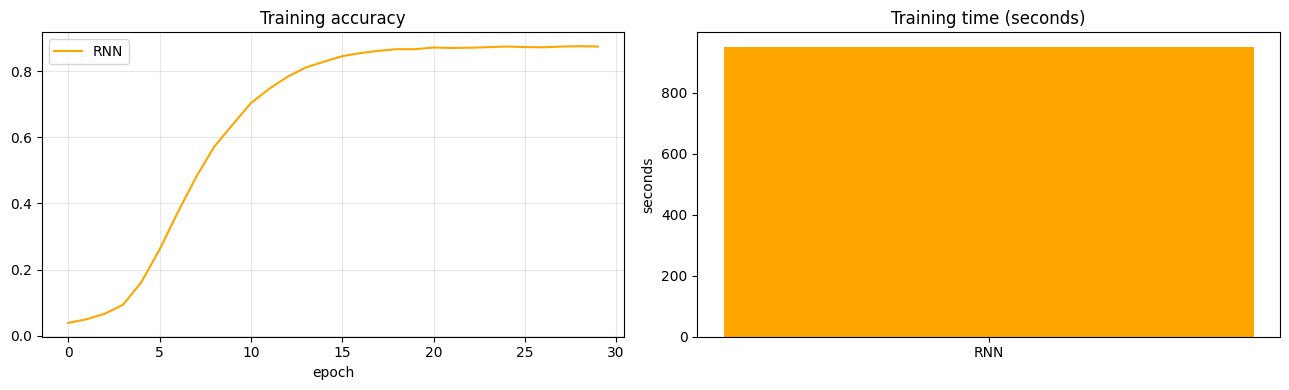

summary:
  RNN   accuracy 87.48% | time 950s


In [68]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors = {"RNN": "orange", "LSTM": "purple", "GRU": "green"}
for name in results:
    ax1.plot(results[name]["history"]["accuracy"], label=name, color=colors[name])
ax1.set_title("Training accuracy") 
ax1.set_xlabel("epoch"); 
ax1.legend(); 
ax1.grid(alpha=0.3)

names = list(results.keys())
times = [results[n]["time"] for n in names]
ax2.bar(names, times, color="orange")
ax2.set_title("Training time (seconds)"); 
ax2.set_ylabel("seconds")
plt.tight_layout(); 
plt.show()

print("summary:")
for name in results:
    acc = results[name]["history"]["accuracy"][-1]
    print(f"  {name:5s} accuracy {acc:.2%} | time {results[name]['time']:.0f}s")

In [70]:
# generate a sample from each so we can compare the TEXT, not just the numbers
def generate_text(model, seed, n_words=12):
    result = seed
    for _ in range(n_words):
        ids = tokenizer.texts_to_sequences([result])[0]
        ids = pad_sequences([ids], maxlen=MAX_LEN - 1, padding="pre")
        pred = model.predict(ids, verbose=0).argmax(axis=1)[0]
        word = next((w for w, i in tokenizer.word_index.items() if i == pred), "")
        result += " " + word
    return result

seed = "my lord"
# for name in models:

print(f"RNN: {generate_text(models[name], seed)}\n")

RNN: my lord more titus lartius are i find t'other and know how we proceed



**What to look for:**
- **Accuracy:** LSTM and GRU usually beat the SimpleRNN on this larger corpus — their gated memory handles the longer word-dependencies Shakespeare has.
- **Speed:** the SimpleRNN is the fastest per epoch (simplest cell); **GRU is usually faster than LSTM** (2 gates vs 3) while scoring similarly — which is exactly why GRU is popular.
- **Text quality:** the LSTM/GRU continuations tend to read more Shakespeare-like. On a small corpus none will be perfect — more data + epochs improves them.

---
## 4. Save all three models + the tokenizer

To use a model later (in our app), we save two things:
- the **model** itself (`.keras` file) — architecture + trained weights,
- the **tokenizer + config** (`.pkl`) — so the app can turn words ↔ numbers the same way.

Without the tokenizer, the saved model is useless — it only understands the integer IDs the tokenizer assigned.

In [71]:
models

{'RNN': <keras.engine.sequential.Sequential at 0x29641dead70>}

In [72]:
os.makedirs("saved", exist_ok=True)

models["RNN"].save("saved/rnn_model.keras")

In [ ]:
os.makedirs("saved", exist_ok=True)

# save each model
for name in models:
    models[name].save(f"saved/{name.lower()}_model.keras")

# save the tokenizer + the sequence length the models expect
with open("saved/tokenizer.pkl", "wb") as f:
    pickle.dump({"tokenizer": tokenizer, "max_len": MAX_LEN}, f)

print("saved files:")
for f in sorted(os.listdir("saved")):
    size = os.path.getsize(f"saved/{f}") / 1024
    print(f"  saved/{f}  ({size:.0f} KB)")

> On Kaggle these files appear in the **/kaggle/working** folder — you can download them (the `saved/` folder) to your laptop to run the app locally, or run the app cell below directly.

In [73]:
# save the tokenizer + the sequence length the models expect
with open("saved/tokenizer.pkl", "wb") as f:
    pickle.dump({"tokenizer": tokenizer, "max_len": MAX_LEN}, f)

---
## 5. A small app that loads a model and generates text

Now the payoff: a tiny **local web app** with **Gradio**. It:
- **loads the saved models from disk** (not the ones in memory — proving the save worked),
- lets you type a **seed phrase**, pick **which model** (RNN/LSTM/GRU), choose how many words,
- and shows the generated text — in your browser.

This is the simplest possible interface: a few lines, runs locally, no deployment.

In [74]:
!pip install gradio --quiet

In [76]:
rnn_model = load_model(r"saved\rnn_model.keras")

with open("saved/tokenizer.pkl", 'rb') as f:
    cfg = pickle.load(f)

In [77]:
generate_text(rnn_model, "my lord", 8)

"my lord more titus lartius are i find t'other and"

In [80]:
cfg['max_len']

12

In [81]:
app_tokenizer = cfg['tokenizer']

In [82]:
app_max_len = cfg['max_len']

In [ ]:
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import pad_sequences

# --- load everything FROM DISK (this is what a real app does) ---
with open("saved/tokenizer.pkl", "rb") as f:
    cfg = pickle.load(f)
app_tokenizer = cfg["tokenizer"]
app_max_len = cfg["max_len"]

app_models = {
    "RNN":  load_model("saved/rnn_model.keras"),
    "LSTM": load_model("saved/lstm_model.keras"),
    "GRU":  load_model("saved/gru_model.keras"),
}
print("loaded models from disk:", list(app_models.keys()))

In [85]:
import gradio as gr

def app_generate(seed, model, n_words):
    if not seed.strip():
        return "Please type a seed phrase."
    
    result = seed.lower()
    for _ in range(int(n_words)):
        ids = app_tokenizer.texts_to_sequences([result])[0]
        ids = pad_sequences([ids], maxlen=app_max_len - 1, padding="pre")
        pred = model.predict(ids, verbose=0).argmax(axis=1)[0]
        word = next((w for w, i in app_tokenizer.word_index.items() if i == pred), "")
        result += " " + word
    return result

demo = gr.Interface(
    fn=app_generate,
    inputs=[
        gr.Textbox(label="Seed phrase", value="my lord"),
        gr.Radio(["RNN", "LSTM", "GRU"], label="Model", value="LSTM"),
        gr.Slider(1, 30, value=12, step=1, label="Words to generate"),
    ],
    outputs=gr.Textbox(label="Generated text"),
    title="Shakespeare Text Generator",
    description="Type a seed, pick a model, and generate Shakespeare-style text.",
)
demo.launch(share=False)   # share=False = local only; set True for a temporary public link

ImportError: cannot import name 'sentinel' from 'typing_extensions' (c:\Users\DIPLAB\.conda\envs\tf-ai\lib\site-packages\typing_extensions.py)

> **To run this on your laptop instead of Kaggle:**
> 1. Download the `saved/` folder (the 3 `.keras` files + `tokenizer.pkl`).
> 2. On your laptop: `pip install tensorflow gradio`.
> 3. Put the app code (the load-from-disk cell + the Gradio cell) into a file `app.py` and run `python app.py`.
> 4. It opens in your browser at `http://127.0.0.1:7860`.
>
> A ready-to-run `app.py` version is in the last cell.

### Standalone `app.py` (for running locally)
Copy this into a file called `app.py` next to your `saved/` folder, then run `python app.py`.

In [ ]:
app_code = '''
import pickle
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import pad_sequences

with open("saved/tokenizer.pkl", "rb") as f:
    cfg = pickle.load(f)
tokenizer, max_len = cfg["tokenizer"], cfg["max_len"]

models = {
    "RNN":  load_model("saved/rnn_model.keras"),
    "LSTM": load_model("saved/lstm_model.keras"),
    "GRU":  load_model("saved/gru_model.keras"),
}

def generate(seed, model_name, n_words):
    if not seed.strip():
        return "Please type a seed phrase."
    result = seed.lower()
    for _ in range(int(n_words)):
        ids = tokenizer.texts_to_sequences([result])[0]
        ids = pad_sequences([ids], maxlen=max_len - 1, padding="pre")
        pred = models[model_name].predict(ids, verbose=0).argmax(axis=1)[0]
        word = next((w for w, i in tokenizer.word_index.items() if i == pred), "")
        result += " " + word
    return result

gr.Interface(
    fn=generate,
    inputs=[gr.Textbox(label="Seed phrase", value="my lord"),
            gr.Radio(["RNN", "LSTM", "GRU"], label="Model", value="LSTM"),
            gr.Slider(1, 30, value=12, step=1, label="Words to generate")],
    outputs=gr.Textbox(label="Generated text"),
    title="Shakespeare Text Generator",
).launch()
'''
with open("app.py", "w") as f:
    f.write(app_code)
print("wrote app.py  — download it with the saved/ folder and run:  python app.py")

---
## Your turn (solo task) ✍️

Pick at least two:
1. **Train on more text** — raise the `text[:40000]` slice (or the whole file) and more epochs. Do LSTM/GRU pull further ahead of the RNN?
2. **Stack two recurrent layers** (first with `return_sequences=True`). Better text?
3. **Add "temperature"** to generation — instead of always taking `argmax`, sample from the probabilities so the text is more creative (hint: `np.random.choice`).
4. **Style the app** — add an example seed, or show all three models' outputs side by side.
5. **Run `app.py` on your laptop** with the downloaded `saved/` folder.

In [ ]:
# ===== YOUR EXPERIMENTS HERE =====



---
## Summary

- Trained **RNN, LSTM, and GRU** on word-level Shakespeare with the same setup — only the recurrent layer changed.
- **Compared** them on accuracy, training time, and generated text: LSTM/GRU handle longer word-dependencies better; **GRU is faster than LSTM** for similar quality (2 gates vs 3).
- **Saved** each model (`.keras`) plus the **tokenizer** (`.pkl`) — you need both to use a model later.
- Built a **small local app** with Gradio that **loads a model from disk** and generates text from a seed — pick the model, type a seed, get Shakespeare.
- Wrote a standalone **`app.py`** to run the same app on a laptop.

**Next:** word embeddings in depth (Word2Vec / GloVe), then attention and Transformers.